In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl

In [42]:
df_res_sob = pd.read_excel('./res_singleobj_modified/IT/results_IT_aveCm_1.xlsx', sheet_name='Sheet1')
df_res_sob.index = pd.to_datetime(df_res_sob.iloc[:, 0])
df_res_sob.drop(columns=['Unnamed: 0'], inplace=True)

Optimal point: λ = 0.3


C:\Users\yangzhec\AppData\Local\Temp\ipykernel_19240\397431000.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis')


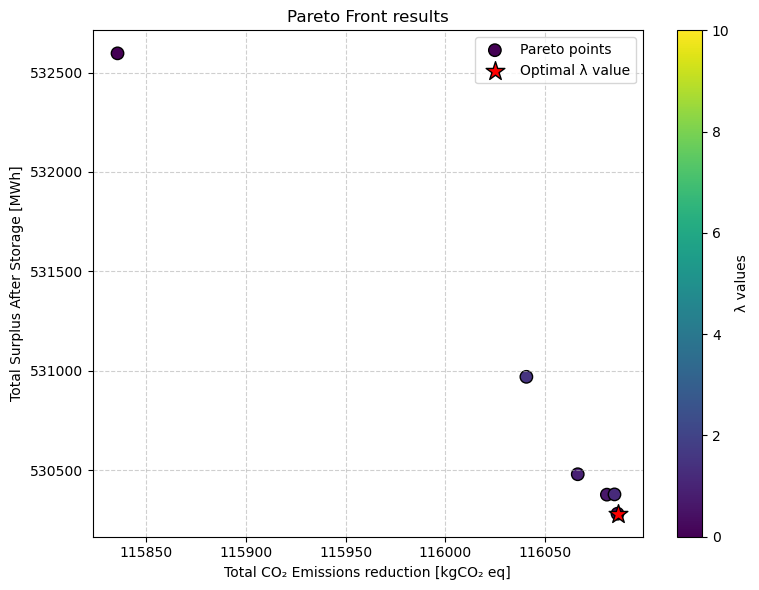

In [43]:
# --- load data and λ values (if needed elsewhere) ---
df_pareto = pd.read_csv('./res_multiobj/pareto_results.csv')
lambdas = np.linspace(0, 10, 11)

# --- set up colormap for λ ---
cmap = mpl.cm.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=lambdas.min(), vmax=lambdas.max())

# --- find the “best” point: lowest surplus ---
idx_best = df_pareto['surplus'].idxmin()
x_best = df_pareto.loc[idx_best, 'co2']
y_best = df_pareto.loc[idx_best, 'surplus']

print(f'Optimal point: λ = {df_pareto.loc[idx_best, "lambda"]}')

# --- plotting ---
plt.figure(figsize=(8, 6))

# scatter all Pareto points colored by λ
sc = plt.scatter(
    df_pareto['co2'],
    df_pareto['surplus'],
    c=df_pareto['lambda'],
    cmap=cmap,
    norm=norm,
    s=80,
    edgecolor='k',
    label='Pareto points'
)

# highlight the best point
plt.scatter(
    x_best,
    y_best,
    color='red',
    marker='*',
    s=200,
    edgecolor='k',
    label='Optimal λ value'
)

plt.xlabel('Total CO₂ Emissions reduction [kgCO₂ eq]')
plt.ylabel('Total Surplus After Storage [MWh]')
plt.title('Pareto Front results')
plt.grid(True, linestyle='--', alpha=0.6)

# colorbar for λ
cbar = plt.colorbar(sc)
cbar.set_label('λ values')

# legend for the star
plt.legend()
plt.tight_layout()
# plt.savefig('./res_multiobj/pareto_front.png', dpi=400)
plt.show()

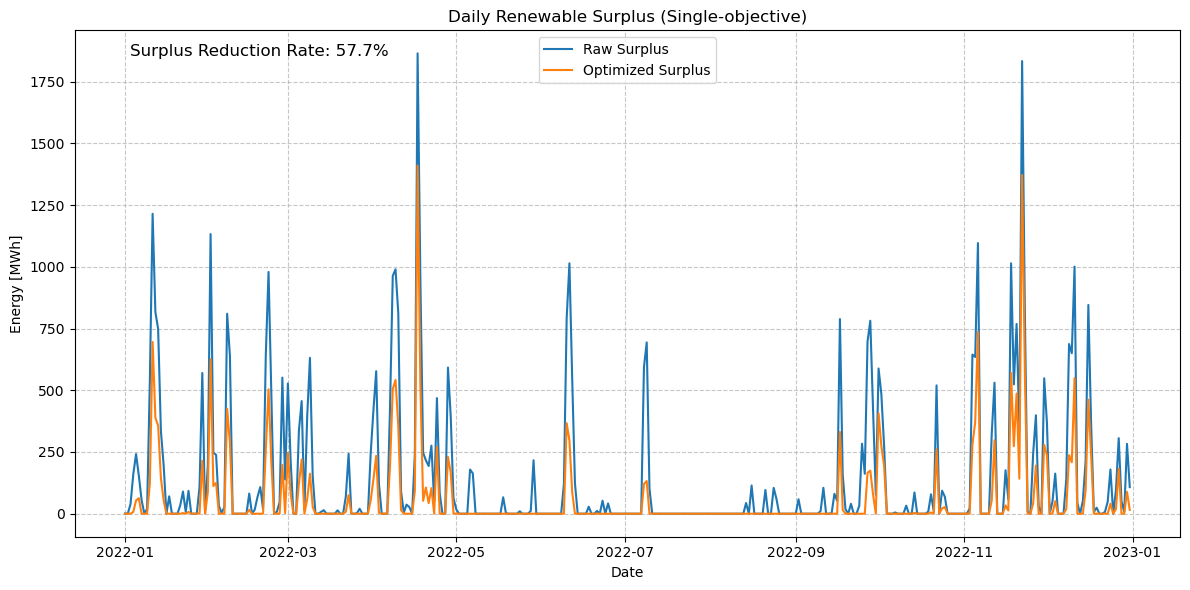

In [44]:
# Calculate total surplus and optimized surplus
total_surplus = df_res_sob['surplus'].sum()
total_optimized_surplus = df_res_sob['surplus_optimized'].sum()

# Calculate reduction rate
reduction_rate = (total_surplus - total_optimized_surplus) / total_surplus * 100

df_daily = df_res_sob.resample('D').mean()

# Create the plot with the reduction rate annotated
plt.figure(figsize=(12, 6))
plt.plot(df_daily.index, df_daily['surplus'], label='Raw Surplus')
plt.plot(df_daily.index, df_daily['surplus_optimized'], label='Optimized Surplus')
plt.title("Daily Renewable Surplus (Single-objective)")
plt.xlabel("Date")
plt.ylabel("Energy [MWh]")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.annotate(f"Surplus Reduction Rate: {reduction_rate:.1f}%", 
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12)
plt.tight_layout()
plt.show()

In [45]:
df_res_mob = pd.read_excel('./res_multiobj_modified/IT/results_IT_aveCm_1_lambda0.3.xlsx', sheet_name='Sheet1')
df_res_mob.index = pd.to_datetime(df_res_mob.iloc[:, 0])
df_res_mob.drop(columns=['Unnamed: 0'], inplace=True)

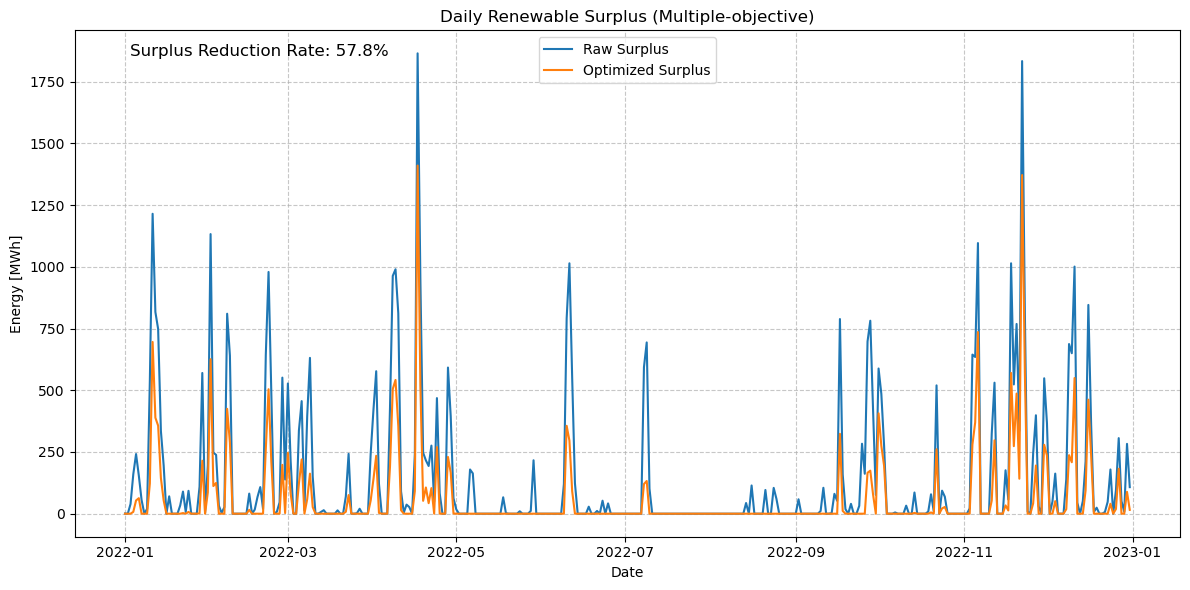

In [46]:
# Calculate total surplus and optimized surplus
total_surplus = df_res_mob['surplus'].sum()
total_optimized_surplus = df_res_mob['surplus_optimized'].sum()

# Calculate reduction rate
reduction_rate = (total_surplus - total_optimized_surplus) / total_surplus * 100

df_daily = df_res_mob.resample('D').mean()

# Create the plot with the reduction rate annotated
plt.figure(figsize=(12, 6))
plt.plot(df_daily.index, df_daily['surplus'], label='Raw Surplus')
plt.plot(df_daily.index, df_daily['surplus_optimized'], label='Optimized Surplus')
plt.title("Daily Renewable Surplus (Multiple-objective)")
plt.xlabel("Date")
plt.ylabel("Energy [MWh]")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.annotate(f"Surplus Reduction Rate: {reduction_rate:.1f}%", 
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12)
plt.tight_layout()
plt.show()

In [47]:
coutry = 'IT'      # Change with other coutries' abbreviations, e.g. ESP, SE, AUT  # noqa: E501
pickle_path = './national_zones/pickled_df'
df_agg = pd.read_pickle(os.path.join(pickle_path, f'df_agg_{coutry}.pkl'))

df_demand = pd.read_pickle(os.path.join(pickle_path, 'df_demand.pkl'))
df_emission = pd.read_pickle(os.path.join(pickle_path, f'emission_{coutry}_2022.pkl'))

In [48]:
df_res_sob['emission factor'] = df_emission['emission_factor'].values
df_res_mob['emission factor'] = df_emission['emission_factor'].values

df_res_sob['pcm_discharge'] = df_res_sob['x_PCM_h'] + df_res_sob['x_PCM_c']
df_res_mob['pcm_discharge'] = df_res_mob['x_PCM_h'] + df_res_mob['x_PCM_c']

df_res_sob['tcm_discharge'] = df_res_sob['x_TCM_h'] + df_res_sob['x_TCM_c']
df_res_mob['tcm_discharge'] = df_res_mob['x_TCM_h'] + df_res_mob['x_TCM_c']

df_res_sob['emission_reduction'] = (df_res_sob['pcm_discharge'] + df_res_sob['tcm_discharge']) * df_res_sob['emission factor']
df_res_mob['emission_reduction'] = (df_res_mob['pcm_discharge'] + df_res_mob['tcm_discharge']) * df_res_mob['emission factor']

In [49]:
print(df_res_sob['emission_reduction'].sum() - df_res_mob['emission_reduction'].sum())

-99.86481049572467


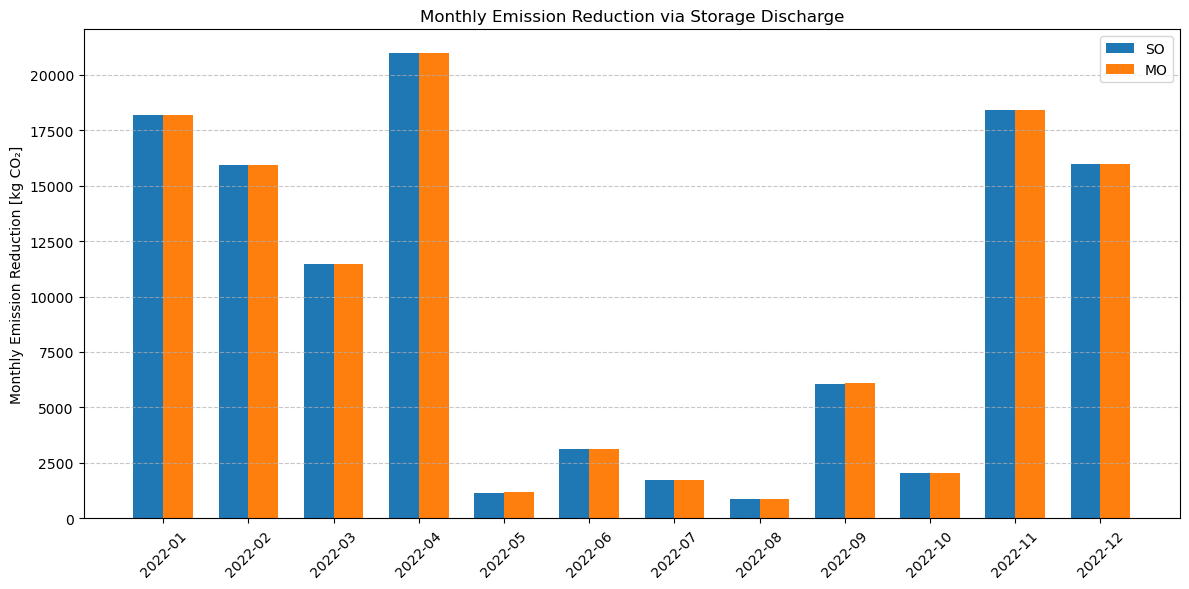

In [51]:
# Convert to period month
df_res_sob['month'] = df_res_sob.index.to_period('M')
df_res_mob['month'] = df_res_mob.index.to_period('M')

# Group by month and sum emission reduction
monthly_emission_sob = df_res_sob.groupby('month')['emission_reduction'].sum()
monthly_emission_mob = df_res_mob.groupby('month')['emission_reduction'].sum()

# Align months
months = monthly_emission_sob.index.astype(str)
x = range(len(months))

# Plot both scenarios
plt.figure(figsize=(12, 6))
width = 0.35
plt.bar([i - width/2 for i in x], monthly_emission_sob.values, width=width, label='SO', color="#1f77b4")
plt.bar([i + width/2 for i in x], monthly_emission_mob.values, width=width, label='MO', color="#ff7f0e")

plt.xticks(x, months, rotation=45)
plt.ylabel("Monthly Emission Reduction [kg CO₂]")
plt.title("Monthly Emission Reduction via Storage Discharge")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

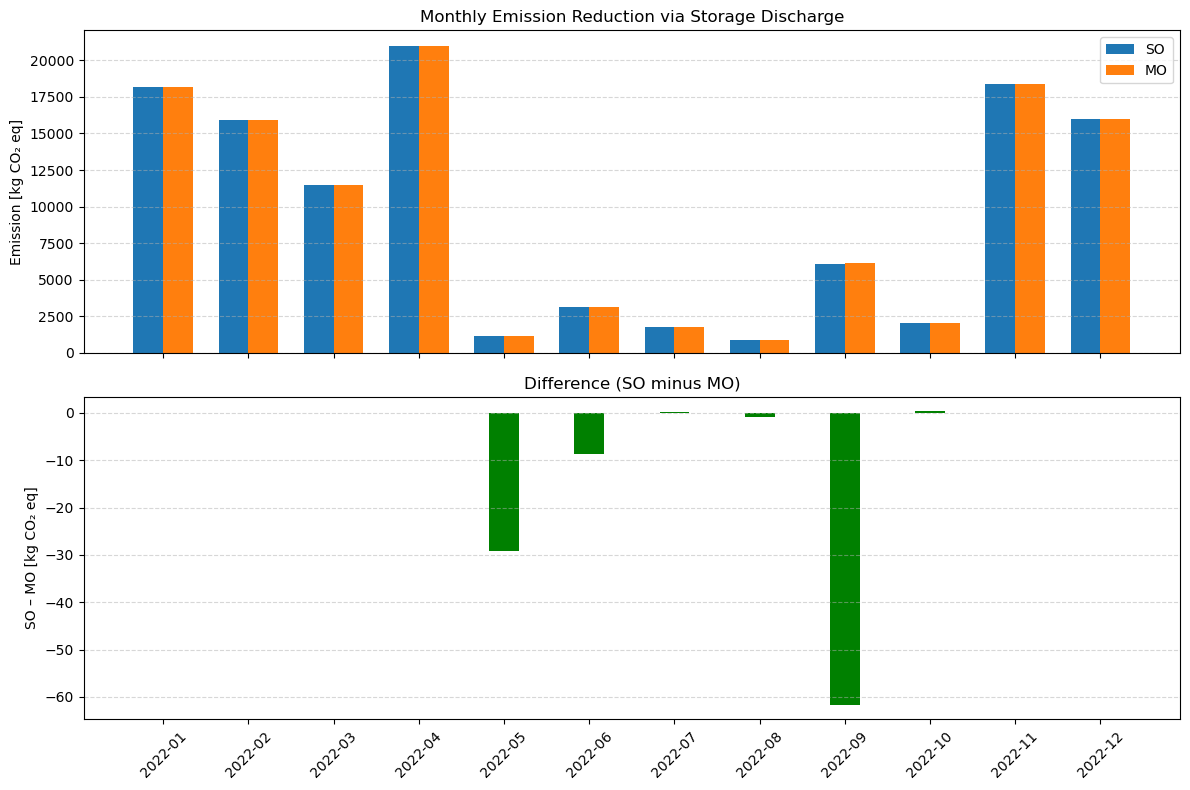

In [57]:
monthly_diff = monthly_emission_sob - monthly_emission_mob

months = monthly_emission_sob.index.astype(str)
x = range(len(months))
width = 0.35
# --- Approach B: SO vs MO on top, difference below ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# upper: SO and MO
ax1.bar([i - width/2 for i in x], monthly_emission_sob.values, width=width, label='SO')
ax1.bar([i + width/2 for i in x], monthly_emission_mob.values, width=width, label='MO')
ax1.set_ylabel("Emission [kg CO₂ eq]")
ax1.set_title("Monthly Emission Reduction via Storage Discharge")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# lower: difference
ax2.bar(x, monthly_diff.values, width=width, color='green')
ax2.set_xticks(x)
ax2.set_xticklabels(months, rotation=45)
ax2.set_ylabel("SO – MO [kg CO₂ eq]")
ax2.set_title("Difference (SO minus MO)")
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [73]:
60/6000

0.01

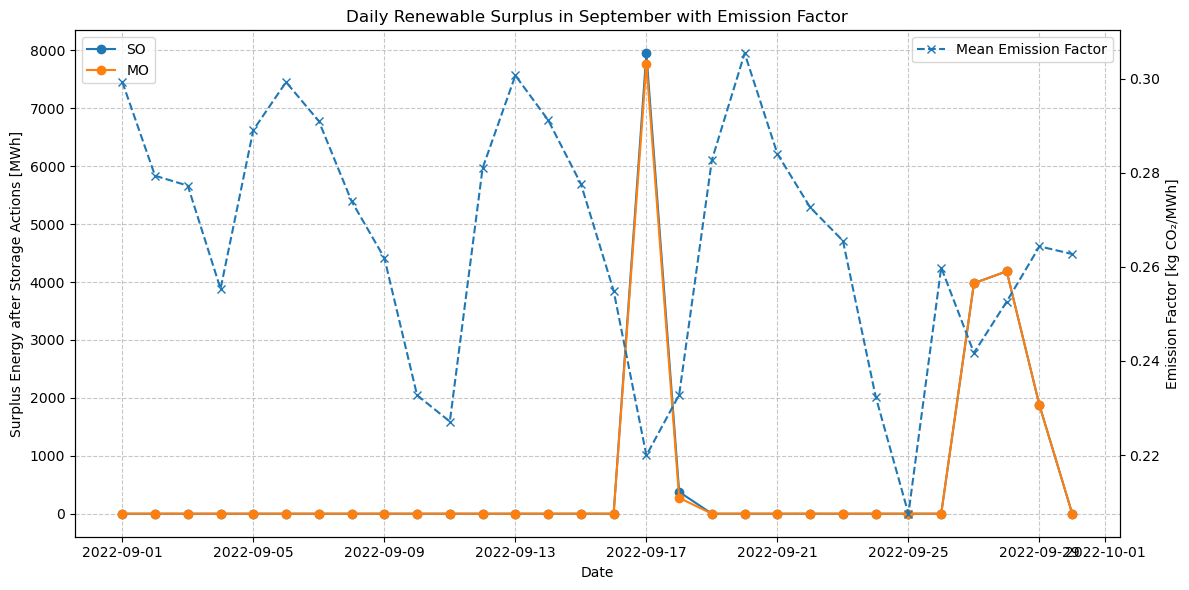

In [ ]:
# — (1) Make sure your index is datetime
df_res_sob.index = pd.to_datetime(df_res_sob.index)
df_res_mob.index = pd.to_datetime(df_res_mob.index)

# — (2) Add a 'day' column with daily periods
df_res_sob['day'] = df_res_sob.index.to_period('D')
df_res_mob['day'] = df_res_mob.index.to_period('D')

# — (3) Filter to September (month == 9)
daily_sob_sep = df_res_sob[df_res_sob.index.month == 9]
daily_mob_sep = df_res_mob[df_res_mob.index.month == 9]

# — (4) Group by the 'day' period and sum the optimized surplus
daily_surplus_sob = daily_sob_sep.groupby('day')['surplus_optimized'].sum()
daily_surplus_mob = daily_mob_sep.groupby('day')['surplus_optimized'].sum()

# — (5) Compute the daily mean emission factor (from the SO data)
daily_mean_ef = daily_sob_sep.groupby('day')['emission factor'].mean()

# — (6) Convert PeriodIndex to timestamps for plotting
dates = daily_surplus_sob.index.to_timestamp()
ef_dates = daily_mean_ef.index.to_timestamp()

# — (7) Plot surplus on primary axis and emission factor on secondary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis: SO vs MO surplus
ax1.plot(dates, daily_surplus_sob.values, label='SO', marker='o')
ax1.plot(dates, daily_surplus_mob.values, label='MO', marker='o')
ax1.set_xlabel("Date")
ax1.set_ylabel("Surplus Energy after Storage Actions [MWh]")
ax1.set_title("Daily Renewable Surplus in September with Emission Factor")
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left')

# Secondary axis: mean emission factor
ax2 = ax1.twinx()
ax2.plot(ef_dates, daily_mean_ef.values, label='Mean Emission Factor', linestyle='--', marker='x')
ax2.set_ylabel("Emission Factor [kg CO₂/MWh]")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

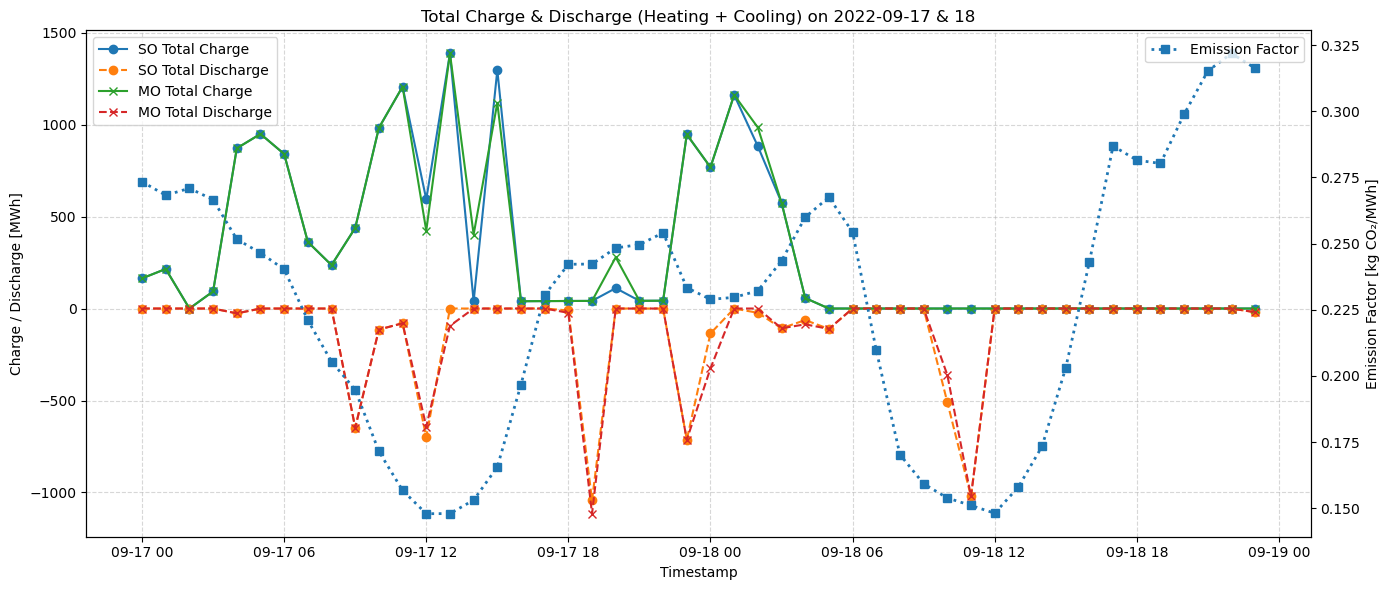

In [ ]:
# — (1) Ensure datetime index
df_res_sob.index = pd.to_datetime(df_res_sob.index)
df_res_mob.index = pd.to_datetime(df_res_mob.index)

# — (2) Compute total charge & discharge (heating + cooling) per timestamp
for df in (df_res_sob, df_res_mob):
    df['total_discharge'] = -(
        df['x_TCM_h'] + df['x_PCM_h'] +
        df['x_TCM_c'] + df['x_PCM_c']
    )
    df['total_charge'] = (
        df['y_TCM_h'] + df['y_PCM_h'] +
        df['y_TCM_c'] + df['y_PCM_c']
    )

# — (3) Select 2022-09-17 & 2022-09-18
start, end = "2022-09-17", "2022-09-18 23:59:59"
sob_sel = df_res_sob.loc[start:end]
mob_sel = df_res_mob.loc[start:end]

# — (4) Prepare the plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot SO charge & discharge
ax1.plot(sob_sel.index, sob_sel['total_charge'],    label='SO Total Charge',    marker='o', linestyle='-')
ax1.plot(sob_sel.index, sob_sel['total_discharge'], label='SO Total Discharge', marker='o', linestyle='--')

# Plot MO charge & discharge
ax1.plot(mob_sel.index, mob_sel['total_charge'],    label='MO Total Charge',    marker='x', linestyle='-')
ax1.plot(mob_sel.index, mob_sel['total_discharge'], label='MO Total Discharge', marker='x', linestyle='--')

ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Charge / Discharge [MWh]")
ax1.set_title("Total Charge & Discharge (Heating + Cooling) on 2022-09-17 & 18")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# — (5) Twin axis for emission factor (from SO data)
ax2 = ax1.twinx()
ax2.plot(
    sob_sel.index, 
    sob_sel['emission factor'], 
    label='Emission Factor', 
    linestyle=':', 
    marker='s', 
    linewidth=2
)
ax2.set_ylabel("Emission Factor [kg CO₂/MWh]")
ax2.legend(loc='upper right')

# — (6) Final layout tweaks
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()